# Predictive Modeling — Supply Chain Forecasting
**Portfolio Project | Data Science**

Three models trained on the engineered feature set from notebook 02:

| Model | Type | Target | Algorithm |
|---|---|---|---|
| **DelayClassifier** | Binary classification | `is_delayed` | XGBoost + GridSearchCV |
| **CostVarianceRegressor** | Regression | `cost_variance_usd` | XGBoost + GridSearchCV |
| **LeadTimeForecaster** | Time-series forecast | daily avg lead time | Prophet (per carrier) |

All supervised models use only **pre-delivery features** — no leakage from
actual arrival data.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

from src.models import DelayClassifier, CostVarianceRegressor, LeadTimeForecaster

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

CARRIER_COLORS = {
    "FastFreight": "#2ecc71", "RelayEx": "#3498db", "PrimeHaul": "#5dade2",
    "SwiftLog": "#f39c12",   "CargoLink": "#e67e22", "NorthStar": "#e74c3c",
    "DirectMove": "#c0392b",
}

DATA = Path("../data")
print("Setup complete.")


Setup complete.


---
## 1. Load Engineered Feature Matrix


In [2]:
df = pd.read_csv(DATA / "shipments_featured.csv", parse_dates=["date"])
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"is_delayed base rate: {df['is_delayed'].mean():.1%}")
print(f"cost_variance_usd mean: ${df['cost_variance_usd'].mean():.3f}")


Loaded: 3,000 rows x 33 columns
Date range: 2023-01-01 to 2024-12-30
is_delayed base rate: 71.8%
cost_variance_usd mean: $0.305


---
## 2. Delay Classifier (XGBoost + GridSearchCV)

**Task:** predict whether a shipment will arrive late, using only information
available at dispatch time (carrier history, lane risk, shipment characteristics,
temporal features).

We use a **time-based train/test split** — train on the first 80% of dates,
test on the remaining 20% — to simulate realistic deployment conditions.


In [3]:
# Time-based split
df_sorted = df.sort_values("date").reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.80)
split_date = df_sorted.loc[split_idx, "date"].date()

train_df = df_sorted.iloc[:split_idx]
test_df  = df_sorted.iloc[split_idx:]

print(f"Train: {len(train_df):,} rows  ({train_df['date'].min().date()} — {train_df['date'].max().date()})")
print(f"Test : {len(test_df):,}  rows  ({test_df['date'].min().date()} — {test_df['date'].max().date()})")
print(f"Split date: {split_date}")
print(f"Train delay rate: {train_df['is_delayed'].mean():.1%}  |  Test delay rate: {test_df['is_delayed'].mean():.1%}")


Train: 2,400 rows  (2023-01-01 — 2024-07-20)
Test : 600  rows  (2024-07-20 — 2024-12-30)
Split date: 2024-07-20
Train delay rate: 70.5%  |  Test delay rate: 76.8%


In [4]:
# Prepare features
X_train_clf, y_train_clf = DelayClassifier.prepare_features(train_df)
X_test_clf,  y_test_clf  = DelayClassifier.prepare_features(test_df)

print(f"Feature matrix: {X_train_clf.shape[1]} features")
print("Features:", list(X_train_clf.columns))


Feature matrix: 21 features
Features: ['month', 'quarter', 'day_of_week', 'is_weekend', 'is_nov_dec', 'weight_bucket', 'weight_kg', 'quantity', 'promised_lead_days', 'freight_cost_usd', 'cost_per_kg', 'rolling_avg_delay', 'rolling_on_time_rate', 'rolling_damage_rate', 'rolling_cost_variance', 'lane_avg_delay', 'lane_delay_rate', 'lane_risk_numeric', 'direction_enc', 'carrier_enc', 'sku_enc']


In [5]:
# Fit with GridSearchCV
clf = DelayClassifier()
clf.fit(X_train_clf, y_train_clf, cv=3, scoring="roc_auc")

print(f"Best params : {clf.best_params_}")
print(f"Best CV AUC : {max(clf.cv_results_['mean_test_score']):.4f}")


Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV AUC : 0.7193


In [6]:
# Evaluate on held-out test set
metrics_clf = clf.evaluate(X_test_clf, y_test_clf)
print("Test-set performance:")
print(f"  AUC       : {metrics_clf['auc']:.4f}")
print(f"  Precision : {metrics_clf['precision']:.4f}")
print(f"  Recall    : {metrics_clf['recall']:.4f}")
print(f"  F1        : {metrics_clf['f1']:.4f}")


Test-set performance:
  AUC       : 0.7667
  Precision : 0.8091
  Recall    : 0.9284
  F1        : 0.8646


### 2a. Confusion Matrix & ROC Curve


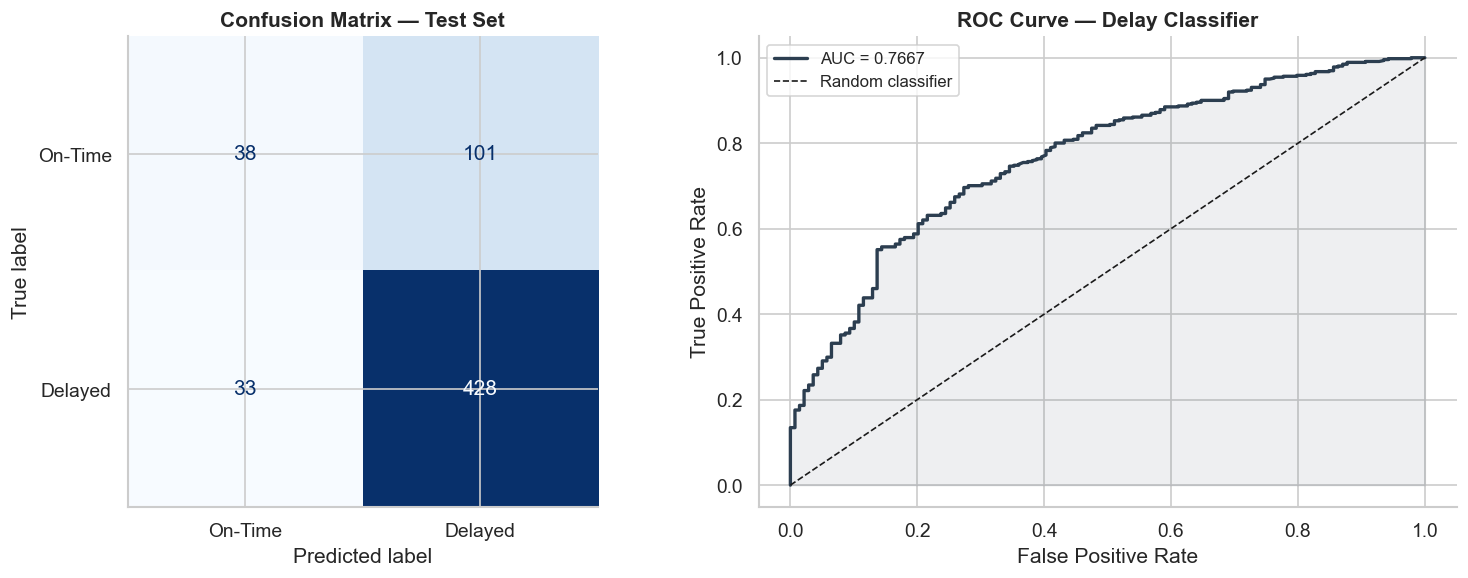

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ax = axes[0]
cm = metrics_clf["confusion_matrix"]
disp = ConfusionMatrixDisplay(cm, display_labels=["On-Time", "Delayed"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontweight="bold")

# ROC curve
ax = axes[1]
y_proba = clf.predict_proba(X_test_clf)
fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
roc_auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color="#2c3e50", lw=2, label=f"AUC = {roc_auc_val:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.08, color="#2c3e50")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Delay Classifier", fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../data/fig_model_clf_roc_cm.png", bbox_inches="tight")
plt.show()


### 2b. SHAP Beeswarm — Which features drive delay predictions?

Each dot is one test-set shipment.
- **Red dots** = high feature value; **blue dots** = low value
- Dots pushed right = increased predicted delay probability


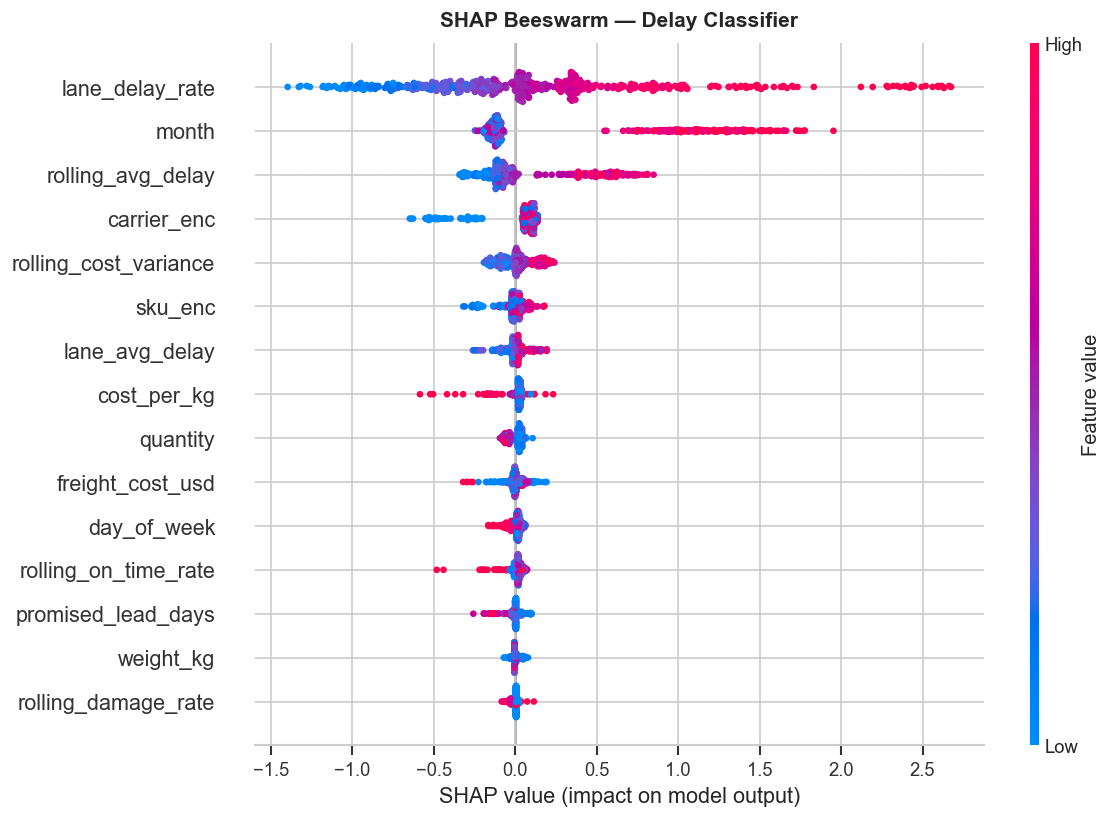

In [8]:
# Compute SHAP on test set (capped at 500 rows for speed)
shap_sample = X_test_clf.sample(min(500, len(X_test_clf)), random_state=42)
shap_exp_clf = clf.shap_explanation(shap_sample)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_exp_clf.values,
    shap_sample,
    plot_type="dot",
    max_display=15,
    show=False,
    plot_size=None,
)
plt.title("SHAP Beeswarm — Delay Classifier", fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("../data/fig_model_clf_shap_beeswarm.png", bbox_inches="tight")
plt.show()


### 2c. Top 10 Feature Importances (mean |SHAP|)


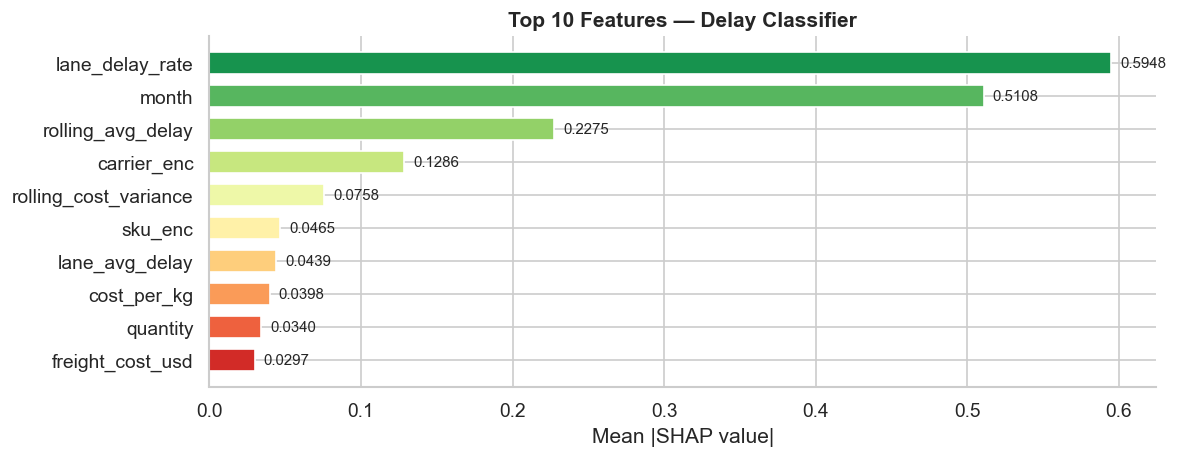

Top 10 features by mean |SHAP|:
  lane_delay_rate                 0.59481
  month                           0.51083
  rolling_avg_delay               0.22746
  carrier_enc                     0.12864
  rolling_cost_variance           0.07580
  sku_enc                         0.04655
  lane_avg_delay                  0.04388
  cost_per_kg                     0.03981
  quantity                        0.03405
  freight_cost_usd                0.02974

Top predictive feature: lane_delay_rate


In [9]:
mean_abs_shap_clf = (
    pd.Series(
        np.abs(shap_exp_clf.values).mean(axis=0),
        index=shap_sample.columns,
    )
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
colors = sns.color_palette("RdYlGn_r", len(mean_abs_shap_clf))
ax.barh(mean_abs_shap_clf.index[::-1], mean_abs_shap_clf.values[::-1],
        color=colors[::-1], edgecolor="white", height=0.65)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 10 Features — Delay Classifier", fontweight="bold")
for i, (feat, val) in enumerate(zip(mean_abs_shap_clf.index[::-1],
                                     mean_abs_shap_clf.values[::-1])):
    ax.text(val + mean_abs_shap_clf.max() * 0.01, i,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/fig_model_clf_importance.png", bbox_inches="tight")
plt.show()

print("Top 10 features by mean |SHAP|:")
for feat, val in mean_abs_shap_clf.items():
    print(f"  {feat:<30s}  {val:.5f}")

top_clf_feature = mean_abs_shap_clf.index[0]
print()
print(f"Top predictive feature: {top_clf_feature}")


---
## 3. Cost Variance Regressor (XGBoost + GridSearchCV)

**Task:** predict the dollar gap between estimated freight cost and the invoiced
amount, using only pre-delivery features.  This helps flag shipments likely to
incur billing overruns before the invoice arrives.


In [10]:
X_train_reg, y_train_reg = CostVarianceRegressor.prepare_features(train_df)
X_test_reg,  y_test_reg  = CostVarianceRegressor.prepare_features(test_df)

reg = CostVarianceRegressor()
reg.fit(X_train_reg, y_train_reg, cv=3)

print(f"Best params : {reg.best_params_}")
print(f"Best CV RMSE: {-max(reg.cv_results_['mean_test_score']):.4f}")


Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV RMSE: 0.3693


In [11]:
metrics_reg = reg.evaluate(X_test_reg, y_test_reg)
print("Test-set performance:")
print(f"  RMSE : ${metrics_reg['rmse']:.4f}")
print(f"  MAE  : ${metrics_reg['mae']:.4f}")
print(f"  R2   : {metrics_reg['r2']:.4f}")


Test-set performance:
  RMSE : $0.3597
  MAE  : $0.2512
  R2   : 0.4627


### 3a. Actual vs Predicted & Residuals


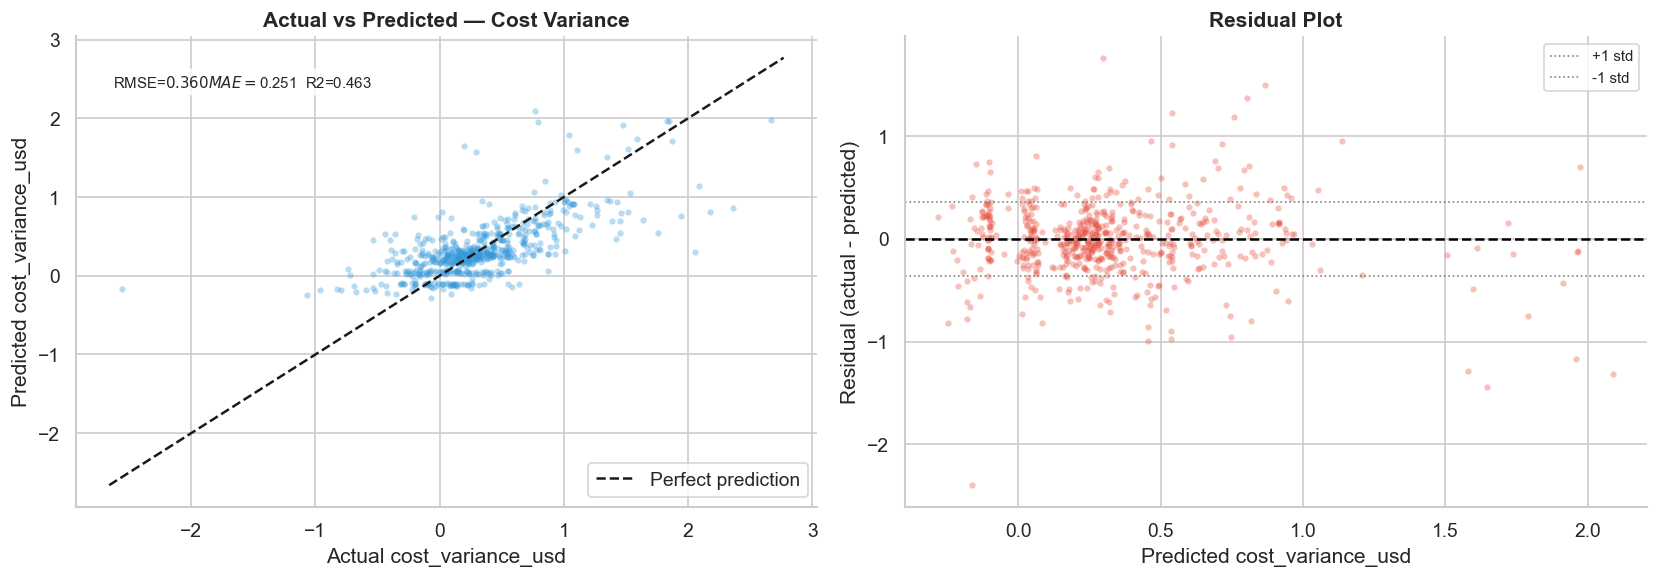

In [12]:
y_pred_reg = reg.predict(X_test_reg)
residuals  = y_test_reg.values - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs predicted scatter
ax = axes[0]
lim_lo = min(y_test_reg.min(), y_pred_reg.min()) - 0.1
lim_hi = max(y_test_reg.max(), y_pred_reg.max()) + 0.1
ax.scatter(y_test_reg, y_pred_reg, alpha=0.35, s=14,
           c="#3498db", linewidths=0, rasterized=True)
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual cost_variance_usd")
ax.set_ylabel("Predicted cost_variance_usd")
ax.set_title("Actual vs Predicted — Cost Variance", fontweight="bold")
ax.legend()
stats_str = (f"RMSE=${metrics_reg['rmse']:.3f}  "
             f"MAE=${metrics_reg['mae']:.3f}  "
             f"R2={metrics_reg['r2']:.3f}")
ax.text(0.05, 0.92, stats_str,
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Residual plot
ax = axes[1]
ax.scatter(y_pred_reg, residuals, alpha=0.35, s=14,
           c="#e74c3c", linewidths=0, rasterized=True)
ax.axhline(0, color="black", lw=1.5, ls="--")
ax.axhline( residuals.std(), color="grey", lw=1, ls=":", label="+1 std")
ax.axhline(-residuals.std(), color="grey", lw=1, ls=":", label="-1 std")
ax.set_xlabel("Predicted cost_variance_usd")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residual Plot", fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../data/fig_model_reg_scatter.png", bbox_inches="tight")
plt.show()


### 3b. SHAP Bar Chart — Cost Variance Drivers


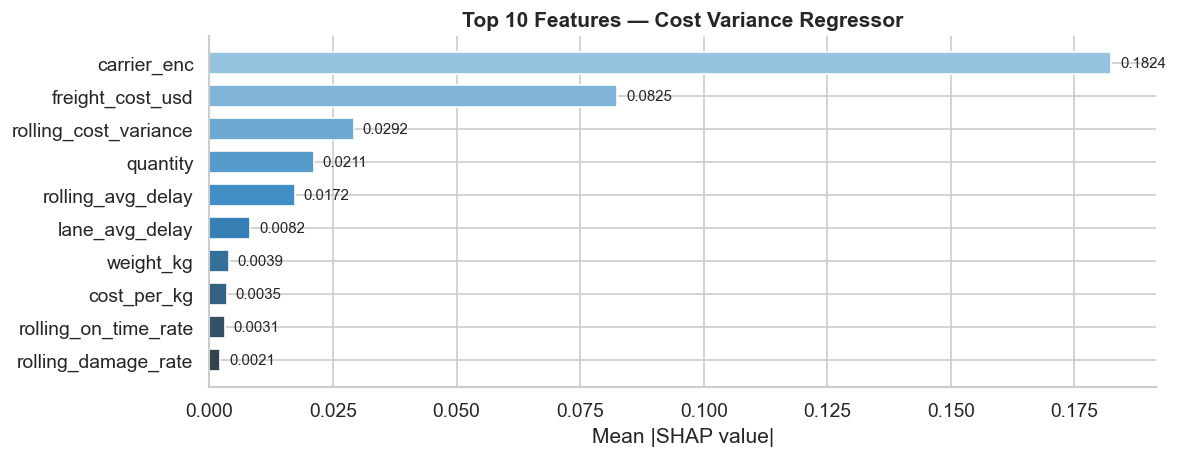

Top predictive feature for cost variance: carrier_enc


In [13]:
shap_sample_reg = X_test_reg.sample(min(500, len(X_test_reg)), random_state=42)
shap_exp_reg    = reg.shap_explanation(shap_sample_reg)

mean_abs_shap_reg = (
    pd.Series(
        np.abs(shap_exp_reg.values).mean(axis=0),
        index=shap_sample_reg.columns,
    )
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
colors = sns.color_palette("Blues_d", len(mean_abs_shap_reg))
ax.barh(mean_abs_shap_reg.index[::-1], mean_abs_shap_reg.values[::-1],
        color=colors[::-1], edgecolor="white", height=0.65)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 10 Features — Cost Variance Regressor", fontweight="bold")
for i, (feat, val) in enumerate(zip(mean_abs_shap_reg.index[::-1],
                                     mean_abs_shap_reg.values[::-1])):
    ax.text(val + mean_abs_shap_reg.max() * 0.01, i,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/fig_model_reg_shap.png", bbox_inches="tight")
plt.show()

top_reg_feature = mean_abs_shap_reg.index[0]
print(f"Top predictive feature for cost variance: {top_reg_feature}")


---
## 4. Lead Time Forecaster (Prophet, per carrier)

**Task:** forecast the average daily lead time for each carrier over the next
30 days, using the full historical shipment record.

Prophet decomposes the time series into trend + weekly + yearly seasonality,
producing 80% confidence intervals around each day's forecast.


In [14]:
# Fit one Prophet model per carrier on the FULL dataset (no train/test split)
df_raw = pd.read_csv(DATA / "shipments.csv", parse_dates=["date"])

forecaster = LeadTimeForecaster(
    forecast_horizon=30,
    yearly_seasonality=True,
    weekly_seasonality=True,
)
forecaster.fit(df_raw)
print(f"Fitted {len(forecaster.models_)} carrier models: {list(forecaster.models_.keys())}")


18:36:59 - cmdstanpy - INFO - Chain [1] start processing


18:37:00 - cmdstanpy - INFO - Chain [1] done processing


18:37:00 - cmdstanpy - INFO - Chain [1] start processing


18:37:00 - cmdstanpy - INFO - Chain [1] done processing


18:37:00 - cmdstanpy - INFO - Chain [1] start processing


...

18:37:01 - cmdstanpy - INFO - Chain [1] start processing


18:37:01 - cmdstanpy - INFO - Chain [1] done processing


18:37:01 - cmdstanpy - INFO - Chain [1] start processing


18:37:01 - cmdstanpy - INFO - Chain [1] done processing


Fitted 7 carrier models: ['CargoLink', 'DirectMove', 'FastFreight', 'NorthStar', 'PrimeHaul', 'RelayEx', 'SwiftLog']


In [15]:
# Generate forecasts
forecasts = forecaster.forecast_all()

# Show tail of one carrier as a sanity check
fc_sample = forecasts["FastFreight"]
last_hist_date = forecaster.history_["FastFreight"]["ds"].max()
future_rows    = fc_sample[fc_sample["ds"] > last_hist_date]
print(f"FastFreight — {len(future_rows)} forecast days")
print(future_rows[["ds","yhat","yhat_lower","yhat_upper"]].tail(5).to_string(index=False))


FastFreight — 30 forecast days
        ds     yhat  yhat_lower  yhat_upper
2025-01-25 6.119936    3.206537    9.054146
2025-01-26 5.972462    2.927857    8.889545
2025-01-27 6.065317    3.251770    9.068071
2025-01-28 5.972488    3.030467    8.947417
2025-01-29 5.998064    3.037358    8.955976


### 4a. 30-Day Forecast — All Carriers

The dashed vertical line marks today (the first forecast date).
Shaded bands show the 80% prediction interval.


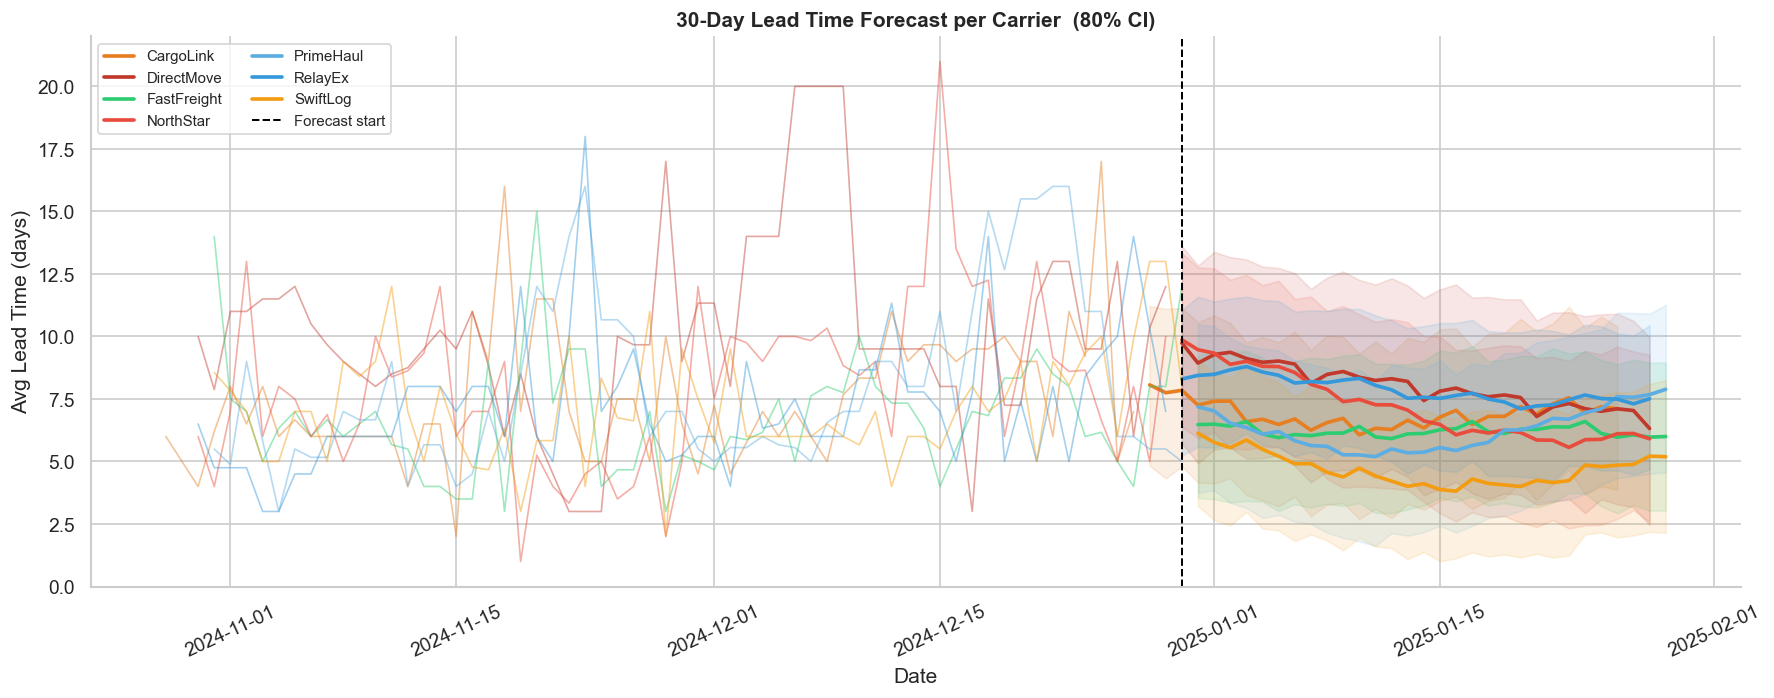

In [16]:
fig, ax = plt.subplots(figsize=(15, 6))

for carrier, fc in forecasts.items():
    color = CARRIER_COLORS[carrier]
    hist  = forecaster.history_[carrier]

    last_hist = hist["ds"].max()
    future    = fc[fc["ds"] > last_hist].copy()

    # Historical line (last 60 days for readability)
    recent_hist = hist[hist["ds"] >= hist["ds"].max() - pd.Timedelta(days=60)]
    ax.plot(recent_hist["ds"], recent_hist["y"],
            color=color, lw=1.0, alpha=0.45)

    # Forecast line + CI band
    ax.plot(future["ds"], future["yhat"],
            color=color, lw=2.2, label=carrier)
    ax.fill_between(future["ds"], future["yhat_lower"], future["yhat_upper"],
                    color=color, alpha=0.12)

ax.axvline(last_hist, color="black", lw=1.2, ls="--", label="Forecast start")
ax.set_xlabel("Date")
ax.set_ylabel("Avg Lead Time (days)")
ax.set_title("30-Day Lead Time Forecast per Carrier  (80% CI)", fontweight="bold")
ax.legend(fontsize=9, ncol=2, loc="upper left")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("../data/fig_model_prophet_forecast.png", bbox_inches="tight")
plt.show()


### 4b. Forecast Summary Table


In [17]:
summary_rows = []
for carrier, fc in forecasts.items():
    last_hist = forecaster.history_[carrier]["ds"].max()
    future = fc[fc["ds"] > last_hist]
    summary_rows.append({
        "carrier":          carrier,
        "forecast_avg_lead": round(future["yhat"].mean(), 2),
        "forecast_hi_ci":   round(future["yhat_upper"].mean(), 2),
        "forecast_lo_ci":   round(future["yhat_lower"].mean(), 2),
        "trend":            round(future["trend"].iloc[-1] - future["trend"].iloc[0], 3),
    })

fc_summary = pd.DataFrame(summary_rows).sort_values("forecast_avg_lead")
print("30-day forecast summary:")
print(fc_summary.to_string(index=False))


30-day forecast summary:
    carrier  forecast_avg_lead  forecast_hi_ci  forecast_lo_ci  trend
   SwiftLog               4.69            7.58            1.80 -0.047
FastFreight               6.22            9.16            3.28  0.028
  PrimeHaul               6.26            9.53            3.00  0.100
  CargoLink               6.92           10.24            3.66  0.008
  NorthStar               7.21           10.60            3.85 -0.020
    RelayEx               7.87           10.73            5.00  0.068
 DirectMove               8.04           11.90            4.18 -0.016


---
## 5. Score Full Dataset

Apply both supervised models to all 3,000 shipments and save to
`data/scored_shipments_full.csv`.  The `in_test_set` flag indicates
which rows were held out during training.


In [18]:
# Score every shipment
X_full_clf, _ = DelayClassifier.prepare_features(df)
X_full_reg, _ = CostVarianceRegressor.prepare_features(df)

df_scored = df.copy()
df_scored["pred_is_delayed"]   = clf.predict(X_full_clf)
df_scored["pred_delay_proba"]  = clf.predict_proba(X_full_clf).round(4)
df_scored["pred_cost_variance"] = reg.predict(X_full_reg).round(4)

# Flag rows that were in the test set
test_ids = set(test_df["shipment_id"])
df_scored["in_test_set"] = df_scored["shipment_id"].isin(test_ids).astype(int)

out_path = DATA / "scored_shipments_full.csv"
df_scored.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Shape: {df_scored.shape}")
print(f"Test-set rows: {df_scored['in_test_set'].sum()}")
print()
print("Score distribution:")
print(df_scored[["pred_is_delayed","pred_delay_proba","pred_cost_variance"]].describe().round(4))


Saved: ..\data\scored_shipments_full.csv
Shape: (3000, 37)
Test-set rows: 600

Score distribution:
       pred_is_delayed  pred_delay_proba  pred_cost_variance
count         3000.000         3000.0000           3000.0000
mean             0.846            0.7161              0.3065
std              0.361            0.1875              0.3740
min              0.000            0.1437             -0.3750
25%              1.000            0.5956              0.0546
50%              1.000            0.7416              0.2589
75%              1.000            0.8729              0.4291
max              1.000            0.9927              4.3785


---
## 6. Model Summary

Key results across all three models in one place.


In [19]:
# Build summary
summary = pd.DataFrame([
    {
        "Model":              "DelayClassifier",
        "Type":               "Binary classification",
        "Target":             "is_delayed",
        "Algorithm":          "XGBoost",
        "Key metric":         f"AUC = {metrics_clf['auc']:.4f}",
        "Also":               f"F1 = {metrics_clf['f1']:.4f}",
        "Top feature":        top_clf_feature,
        "Best params":        str(clf.best_params_),
    },
    {
        "Model":              "CostVarianceRegressor",
        "Type":               "Regression",
        "Target":             "cost_variance_usd",
        "Algorithm":          "XGBoost",
        "Key metric":         f"RMSE = ${metrics_reg['rmse']:.4f}",
        "Also":               f"R2 = {metrics_reg['r2']:.4f}",
        "Top feature":        top_reg_feature,
        "Best params":        str(reg.best_params_),
    },
    {
        "Model":              "LeadTimeForecaster",
        "Type":               "Time-series forecast",
        "Target":             "actual_lead_days (daily avg)",
        "Algorithm":          "Prophet",
        "Key metric":         "30-day horizon per carrier",
        "Also":               "80% prediction interval",
        "Top feature":        "Trend + yearly/weekly seasonality",
        "Best params":        "yearly + weekly seasonality",
    },
])

pd.set_option("display.max_colwidth", 50)
pd.set_option("display.width", 160)
print("=" * 100)
print("MODEL SUMMARY")
print("=" * 100)
print(summary.to_string(index=False))


MODEL SUMMARY
                Model                  Type                       Target Algorithm                 Key metric                    Also                       Top feature                                                  Best params
      DelayClassifier Binary classification                   is_delayed   XGBoost               AUC = 0.7667             F1 = 0.8646                   lane_delay_rate {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
CostVarianceRegressor            Regression            cost_variance_usd   XGBoost             RMSE = $0.3597             R2 = 0.4627                       carrier_enc {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
   LeadTimeForecaster  Time-series forecast actual_lead_days (daily avg)   Prophet 30-day horizon per carrier 80% prediction interval Trend + yearly/weekly seasonality                                  yearly + weekly seasonality
